In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import the required classifier models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score

Exercise 1: Load the Dataset

In [3]:
# Load diabets Dataset
diabets = pd.read_csv('diabetes.csv')
print("Dataset loaded successfully from URL!")

Dataset loaded successfully from URL!


In [4]:
print("the first five rows")
diabets.head()

the first five rows


,768,8,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


In [5]:
print("the last five rows")
diabets.tail()

the last five rows


,768,8,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,0,36.8,0.34,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,0,0,30.1,0.349,47,1
768,1,93,70,31,0,30.4,0.315,23,0


In [6]:
print("shape of the dataset")
diabets.shape

shape of the dataset


(769, 9)

In [7]:
cleanedDiabets=diabets.iloc[1:]

In [8]:
cleanedDiabets = cleanedDiabets.rename(columns={
    '768': 'Pregnancies',
    '8': 'Glucose', 
    'Unnamed: 2': 'BloodPressure',
    'Unnamed: 3': 'SkinThickness',
    'Unnamed: 4': 'Insulin',
    'Unnamed: 5': 'BMI',
    'Unnamed: 6': 'DiabetesPedigreeFunction',
    'Unnamed: 7': 'Age',
    'Unnamed: 8': 'Outcome'
})

In [9]:
cleanedDiabets = cleanedDiabets.apply(pd.to_numeric)
cleanedDiabets

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
764,10,101,76,48,180,32.9,0.171,63,0
765,2,122,70,27,0,36.8,0.340,27,0
766,5,121,72,23,112,26.2,0.245,30,0
767,1,126,60,0,0,30.1,0.349,47,1


Exercise 2: Explore the Dataset

In [ ]:
1. How many rows are there?
   - 768
2. How many columns?
    - 9
3. What are the feature names?
  - ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
4. Which column is the target variable?
 - outcome
5. What are the data types?
 - all are object datatypes
6. Are there missing values?
 - no missing value

In [ ]:
7. Display statistical summary.

In [10]:
cleanedDiabets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 1 to 768
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [17]:
cleanedDiabets.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
cleanedDiabets.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Exercise 3: Data Cleaning

In [12]:
# Part A : Check if there are any duplicate rows and removing them
duplicateRows = cleanedDiabets.duplicated()
print(f"Number of duplicate rows: {duplicateRows.sum()}")
print(f"Duplicate rows exist: {duplicateRows.any()}")

Number of duplicate rows: 0
Duplicate rows exist: False


In [13]:
# Part B : checking if there are 0 values
print (" there are no zero values in the selected columns")
# List of columns to check
checkColumns= ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count zero values in each column
for column in checkColumns:
    zero_count = (cleanedDiabets[column] == 0).sum()
    print(f"{column}: {zero_count} zero values")

 there are no zero values in the selected columns
Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


In [14]:
checkColumns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
# Part C - replace 0 with NaN in target columns only
cleanedDiabets[checkColumns] = cleanedDiabets[checkColumns].replace(0, np.nan)

# Part D - Replace missing values using the median of each column
cleanedDiabets = cleanedDiabets.fillna(cleanedDiabets.median())

Exercise 4: Exploratory Data Analysis

In [23]:
df = cleanedDiabets

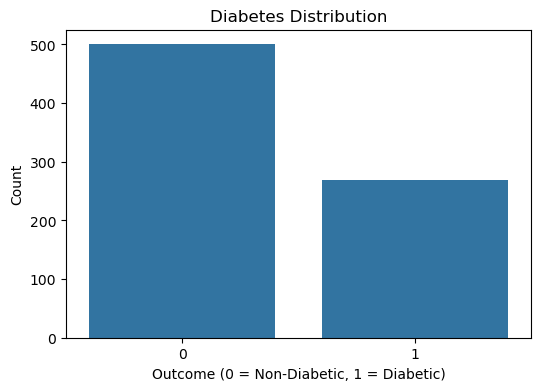

In [16]:
# Chart 1
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

Questions
Is the dataset balanced?
  - no
Which class appears more often?
  - the Non-Diabetic

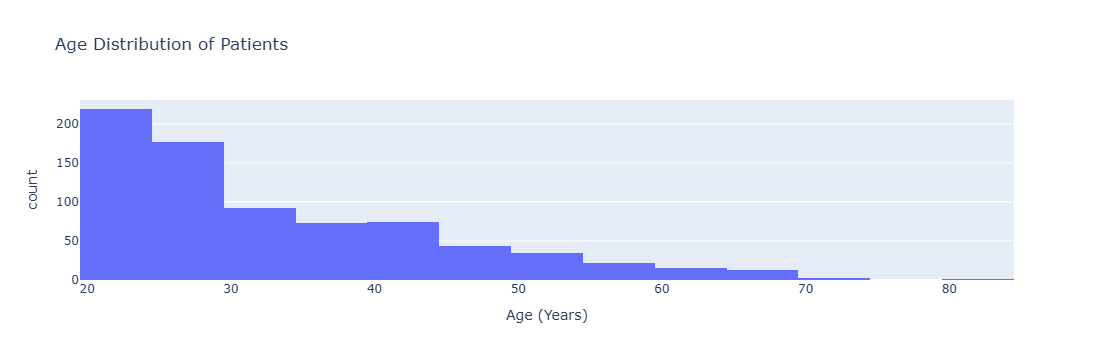

In [17]:
# Chart 2
fig = px.histogram(
    df,
    x="Age",
    nbins=20,
    title="Age Distribution of Patients",
    labels={"Age": "Age (Years)", "count": "Number of Patients"}
)

fig.show()

Questions
Which age group appears most?
 - 20 -30
Is the distribution symmetric?
  - no its not

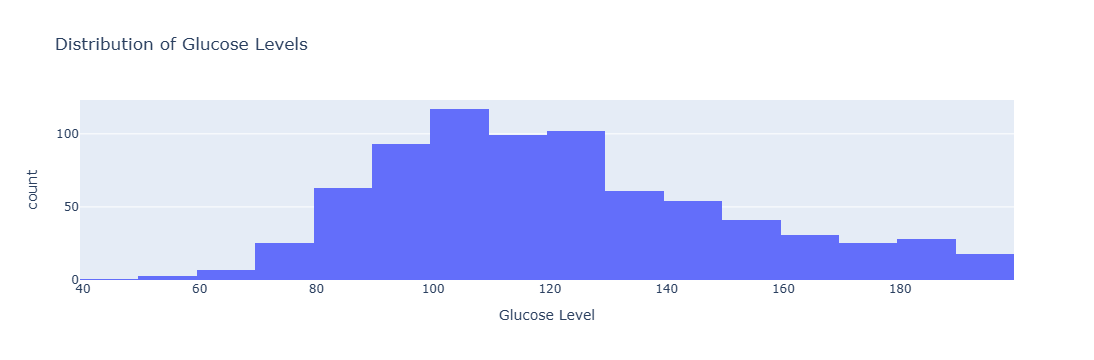

In [18]:
# chart 3
fig = px.histogram(
    df,
    x="Glucose",
    nbins=25,
    title="Distribution of Glucose Levels",
    labels={"Glucose": "Glucose Level", "count": "Frequency"}
)

fig.show()

Questions
Are glucose values normally distributed?
 - no but its fairly distributed
Are there outliers?
 - yes values above 180–200 represent high glucose levels compared to the majority of the data.

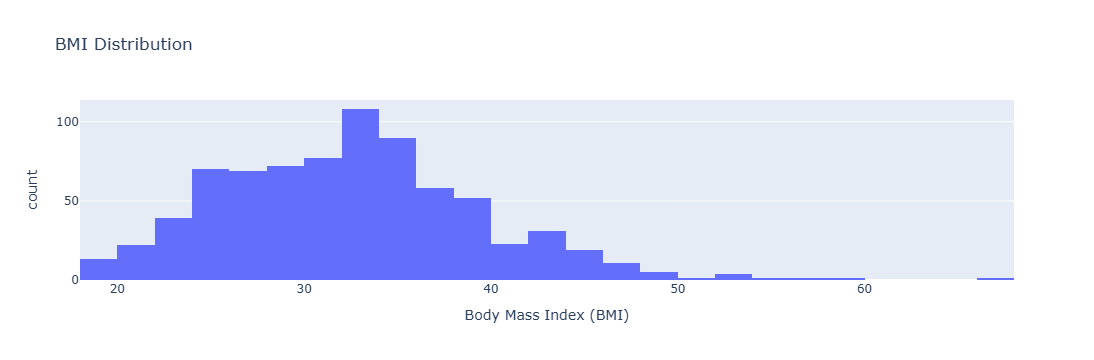

In [20]:
# chart 4
fig = px.histogram(
    df,
    x="BMI",
    nbins=40,
    title="BMI Distribution",
    labels={"BMI": "Body Mass Index (BMI)", "count": "Frequency"}
)

fig.show()

Questions
Are most patients overweight?
 - yes
Are there extreme values?
 - yes 

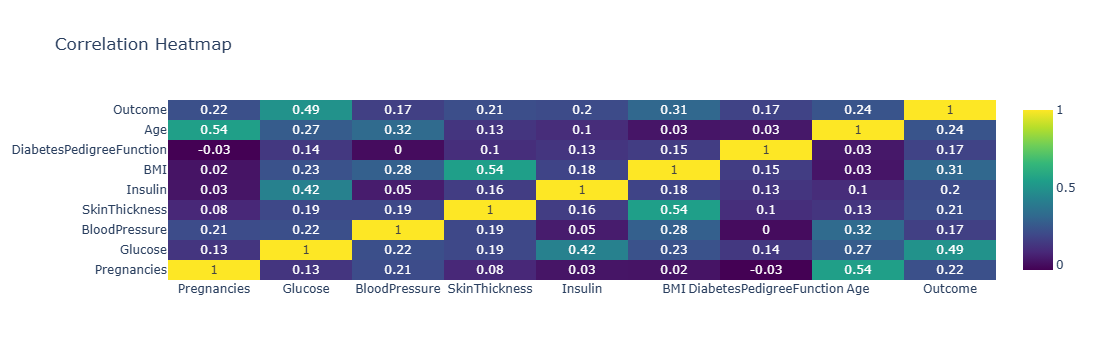

In [21]:
# chart 5 
corr = df.corr(numeric_only=True)

fig = go.Figure(data=go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.columns,
    colorscale="Viridis",
    text=corr.round(2).values,
    texttemplate="%{text}"
))

fig.update_layout(title="Correlation Heatmap")

fig.show()

Questions
Which feature has the strongest correlation with Outcome?
 - Glucose with a positive correlation coefficient of approximately 0.47–0.49
Which two features are highly correlated?
 - Age and Pregnancies with a positive correlation coefficient of approximately 0.54

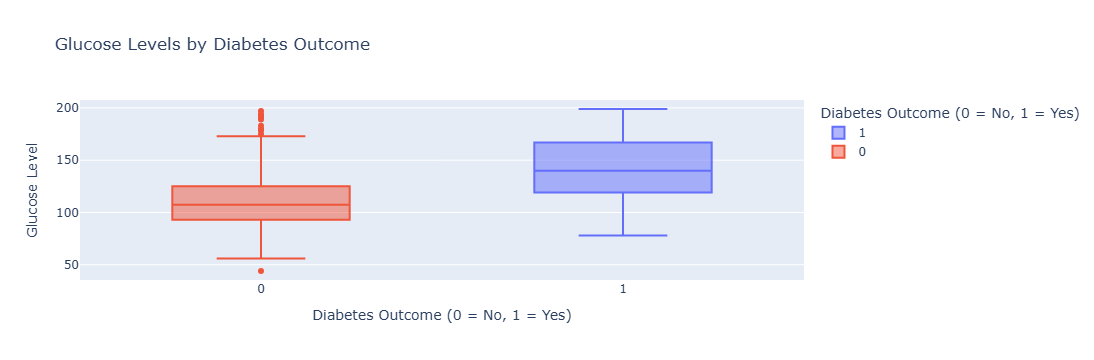

In [22]:
# chart 6
fig = px.box(
    df,
    x="Outcome",
    y="Glucose",
    color="Outcome",
    title="Glucose Levels by Diabetes Outcome",
    labels={
        "Outcome": "Diabetes Outcome (0 = No, 1 = Yes)",
        "Glucose": "Glucose Level"
    }
)

fig.show()

Question
Do diabetic patients generally have higher glucose levels?
Yes. The chart shows that the median glucose level for diabetic patients  ~140 which is significantly higher than non-diabetic patients

In [42]:
# Exercise 5: Prepare the Data
# Exclude the target column 'Outcome' from features
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# Exercise 6: Split the Dataset
x_mtrain, x_mtest, y_mtrain, y_mtest = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)

In [43]:
# Exercise 7: Feature Scaling
scaler = StandardScaler()
x_mtrain = scaler.fit_transform(x_mtrain)
x_mtest = scaler.transform(x_mtest)

Exercise 8: Train Multiple Models
Train the following classifiers.
Model 1
Logistic Regression

Model 2
Decision Tree

Model 3

Random Forest

Model 4
Support Vector Machine (SVM)

Model 5
K-Nearest Neighbors (KNN)

In [44]:
# Model 1: Logistic Regression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(x_mtrain, y_mtrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
# Model 2: Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_mtrain, y_mtrain)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
# Model 3: Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_mtrain, y_mtrain)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Model 4: Support Vector Machine (SVM)
model_svm = SVC(random_state=42)
model_svm.fit(x_mtrain, y_mtrain)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [48]:
# Model 5: K-Nearest Neighbors (KNN)
model_knn = KNeighborsClassifier()
model_knn.fit(x_mtrain, y_mtrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
# Store trained models in a dictionary for easy iteration
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "Support Vector Machine": model_svm,
    "K-Nearest Neighbors": model_knn,
}

# Collect evaluation results
results = []

for name, model in models.items():
    # Predict on test data
    y_pred = model.predict(x_mtest)

    # Calculate metrics
    acc = accuracy_score(y_mtest, y_pred)
    prec = precision_score(y_mtest, y_pred)
    rec = recall_score(y_mtest, y_pred)
    f1 = f1_score(y_mtest, y_pred)

    results.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1 Score": round(f1, 4),
        }
    )

# Display results as a clean DataFrame
evaluation_df = pd.DataFrame(results)
display(evaluation_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7532,0.6667,0.6182,0.6415
1,Decision Tree,0.7143,0.5965,0.6182,0.6071
2,Random Forest,0.7338,0.6250,0.6364,0.6306
3,Support Vector Machine,0.7468,0.6667,0.5818,0.6214
4,K-Nearest Neighbors,0.7208,0.5968,0.6727,0.6325


Exercise 12: Interpretation Questions
Answer the following.
Question 1
What is Classification?
 - Classification is a Supervised ML task where a model learns from historical data to categorize input data into discrete classes or labels (e.g., Spam vs. Not Spam, Has Diabetes vs. No Diabetes)
Question 2
Why is this a binary classification problem?
 - Because the target variable (Outcome) has only two possible outcomes:1 $\rightarrow$ Patient has diabetes.0    $\rightarrow$ Patient does not have diabetes.
Question 3
Explain
Accuracy - The proportion of total correct predictions (both positive and negative) out of all predictions made.
Precision - The proportion of true positive predictions out of everything predicted as positive. It measures prediction exactness.
Recall - The proportion of actual positive cases that the model correctly identified. It measures completeness.
F1 Score - The harmonic mean of Precision and Recall. It balances both metrics, especially useful when dealing with imbalanced datasets.

Question 4
What is a False Positive?
Give a real-life example.
  - A False Positive (Type I Error) occurs when the model predicts a positive outcome, but the true label is negative (a       false alarm).Real-life Example: A medical test predicts a healthy patient has diabetes when they actually do not
Question 5
What is a False Negative?
Give a real-life example.
 - A False Negative (Type II Error) occurs when the model predicts a negative outcome, but the true label is positive (a      missed case). Real-life Example: A medical test predicts a patient is healthy when they actually have diabetes.

Question 6
Which error is more dangerous in diabetes prediction?
- A False Negative is significantly more dangerous in medical diagnosis.
  Why? If a patient receives a False Positive, follow-up blood tests will clear up the mistake with minimal risk. But if a   patient receives a False Negative, an active disease goes untreated, potentially leading to severe, life-threatening       health complications down the road.

Question 7
Why should we save the trained model?
 - Saving (serializing) the trained model using tools like pickle or joblib allows you to deploy it into production           without having to retrain it every time you receive new data. It saves computation time and memory.
Question 8
Why should we save the feature metadata?
 - Feature metadata (such as feature names, order, and scaler parameters like mean and standard deviation) ensures that       new input data in production is transformed identically to the training data. Without matching feature ordering and        scaling, the model will produce incorrect or corrupted predictions.